# 04 — Regresión Logística

## Introducción

**Objetivo.** Entrenar, evaluar e interpretar **Regresión Logística** en el marco *screening* (honesto).

**Fundamento teórico.** Modelo lineal que estima P(y=1) con la función logística sobre una combinación lineal de features.

**Ventajas.** Interpretable (coeficientes ≈ log-odds), rápida, buena línea base, probabilidades calibradas.

**Limitaciones.** Asume linealidad en el log-odds; limitada ante interacciones no lineales.

**Casos de uso.** Línea base y herramienta explicable en entornos clínicos.


In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../src'))
import warnings; warnings.simplefilter('ignore')
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from predia_ml import config, data, evaluate, plots
pd.set_option('display.max_columns', 60)


In [2]:
NAME = 'logistic_regression'
sp = joblib.load(config.DATASETS_DIR/'split_screening.joblib')
X_test, y_test = sp['X_test'], sp['y_test']
est = joblib.load(config.MODELS_DIR/f'screening_{NAME}.joblib')
meta = json.load(open(config.METRICS_DIR/f'screening_{NAME}.json'))
print('Mejores hiperparámetros:'); print(json.dumps(meta['best_params'], indent=2))
print('CV ROC AUC:', round(meta['cv_roc_auc'],4), '| fit_time(s):', meta['fit_time_sec'], '| submuestreo:', meta['subsampled'])

Mejores hiperparámetros:
{
  "clf__C": 0.008263688714158009,
  "clf__class_weight": "balanced",
  "clf__penalty": "l2"
}
CV ROC AUC: 0.661 | fit_time(s): 8.29 | submuestreo: False


### Evaluación en test (recalculada en ejecución)

In [3]:
y_pred = est.predict(X_test); y_proba = est.predict_proba(X_test)[:,1]
m = evaluate.compute_metrics(y_test, y_pred, y_proba)
pd.Series({k: round(v,4) for k,v in m.items()}).to_frame('valor')

,valor
accuracy,0.6044
balanced_accuracy,0.6136
precision,0.7144
recall_sensitivity,0.5675
specificity,0.6597
f1,0.6325
mcc,0.2229
tn,5278.0000
fp,2722.0000
fn,5190.0000


### Curvas ROC, Precision-Recall, matriz de confusión y calibración

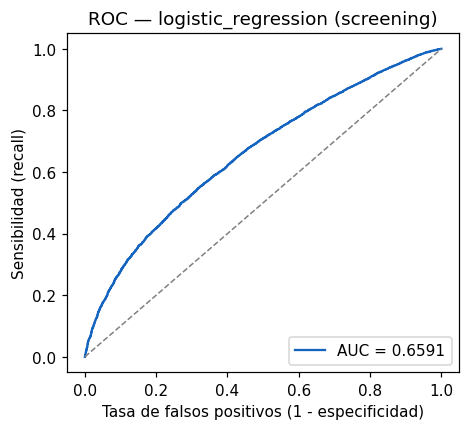

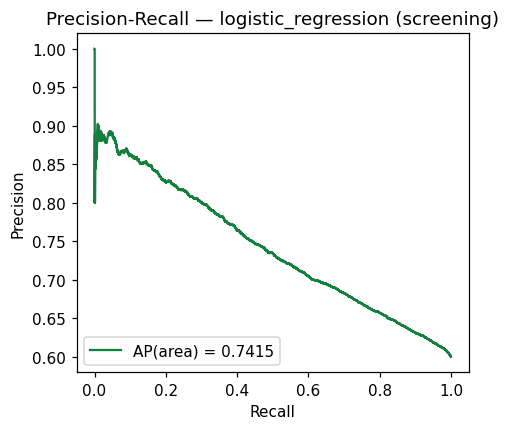

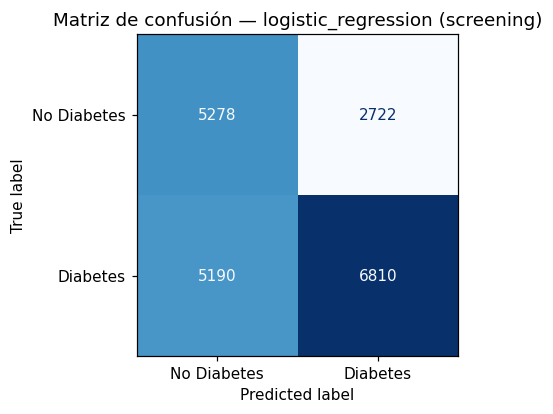

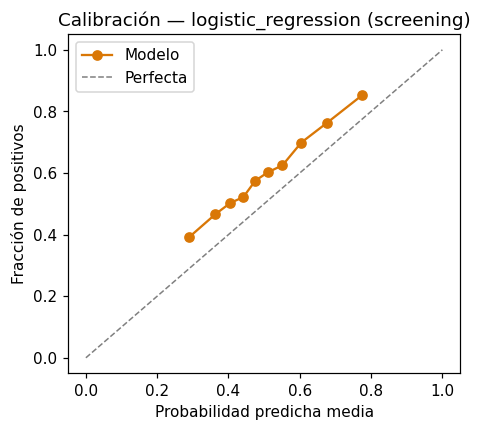

In [4]:
for kind in ['roc','pr','cm','cal']:
    p = config.FIGURES_DIR/'models'/f'{kind}_screening_{NAME}.png'
    if p.exists(): display(Image(filename=str(p)))